In [4]:
# fusion.py — trộn muộn, không train lại gì, vài giây
import numpy as np, pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score as AP, precision_recall_curve

MEM = ["V0_lgb", "V1e_lgb", "V0_xgb", "sage"]   # thêm V1e_xgb, V2e_lgb, V3e_lgb, sage_noedge tuỳ ý
meta = pd.read_parquet("dataset_high/transaction_features.parquet",
                       columns=["Is Laundering", "split"])
y = {s: meta.loc[meta.split == s, "Is Laundering"].to_numpy("int8") for s in ("val", "test")}

def logit(p):
    p = np.clip(p.astype("float64"), 1e-7, 1 - 1e-7); return np.log(p / (1 - p))
def L(m, s, k):
    return logit(np.load(f"scores/scores-v3/sage_lstm_seed{s}_{k}-v3.npy" if m == "sage"
                         else f"scores/{m}_seed{s}_{k}.npy"))
def f1(yy, pred):
    tp = np.count_nonzero(pred & (yy == 1)); fp = np.count_nonzero(pred & (yy == 0))
    fn = np.count_nonzero((~pred) & (yy == 1))
    return 0.0 if tp == 0 else 2 * tp / (2 * tp + fp + fn)
def best_thr(yy, ss):
    p, r, t = precision_recall_curve(yy, ss); f = 2 * p * r / (p + r + 1e-12)
    return float(t[np.argmax(f[:-1])])

rows = []
for s in range(4):
    A = {m: {k: L(m, s, k) for k in ("val", "test")} for m in MEM}
    Xv = np.column_stack([A[m]["val"] for m in MEM])
    Xt = np.column_stack([A[m]["test"] for m in MEM])
    lr = LogisticRegression(max_iter=2000).fit(Xv, y["val"])
    pv, pt = lr.predict_proba(Xv)[:, 1], lr.predict_proba(Xt)[:, 1]
    rows.append(dict(seed=s, ap=AP(y["test"], pt),
                     f1=f1(y["test"], pt >= best_thr(y["val"], pv)),
                     f1_05=f1(y["test"], pt >= 0.5),
                     **{f"w_{m}": round(c, 3) for m, c in zip(MEM, lr.coef_[0])}))
    print(rows[-1])
d = pd.DataFrame(rows)
print(d.round(4).to_string(index=False))
print(f"TB: ap {d.ap.mean():.4f} ± {d.ap.std():.4f} | f1 {d.f1.mean():.4f} ± {d.f1.std():.4f} "
      f"| f1@0.5 {d.f1_05.mean():.4f} ± {d.f1_05.std():.4f}")

{'seed': 0, 'ap': 0.7049572491721501, 'f1': 0.7151712887438826, 'f1_05': 0.6917500862961684, 'w_V0_lgb': np.float64(0.112), 'w_V1e_lgb': np.float64(0.273), 'w_V0_xgb': np.float64(0.582), 'w_sage': np.float64(0.167)}
{'seed': 1, 'ap': 0.710440554202072, 'f1': 0.7226061204343535, 'f1_05': 0.7015742642026009, 'w_V0_lgb': np.float64(-0.153), 'w_V1e_lgb': np.float64(0.458), 'w_V0_xgb': np.float64(0.627), 'w_sage': np.float64(0.18)}
{'seed': 2, 'ap': 0.714654840421563, 'f1': 0.7240473061760841, 'f1_05': 0.7055612418969635, 'w_V0_lgb': np.float64(0.0), 'w_V1e_lgb': np.float64(0.399), 'w_V0_xgb': np.float64(0.674), 'w_sage': np.float64(0.157)}
{'seed': 3, 'ap': 0.7032934566328944, 'f1': 0.7115067589845038, 'f1_05': 0.6861313868613139, 'w_V0_lgb': np.float64(0.248), 'w_V1e_lgb': np.float64(0.24), 'w_V0_xgb': np.float64(0.435), 'w_sage': np.float64(0.171)}
 seed     ap     f1  f1_05  w_V0_lgb  w_V1e_lgb  w_V0_xgb  w_sage
    0 0.7050 0.7152 0.6918     0.112      0.273     0.582   0.167
    1 0.7

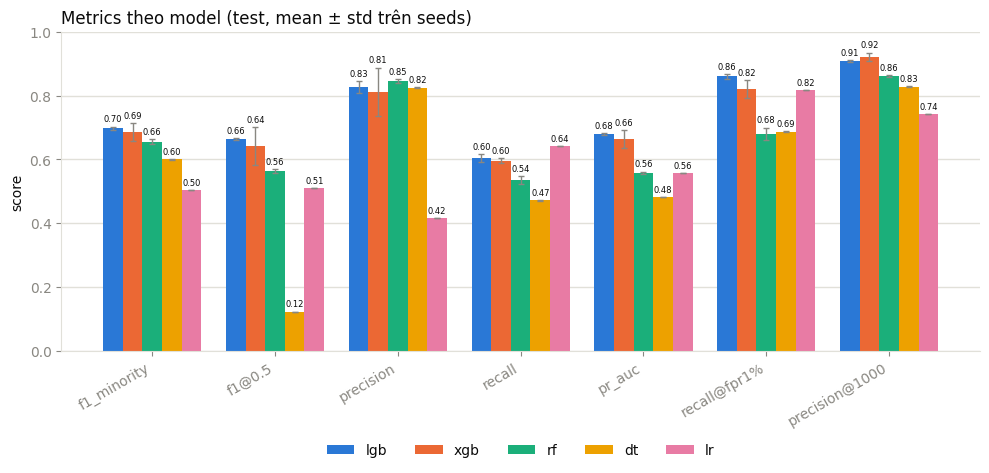

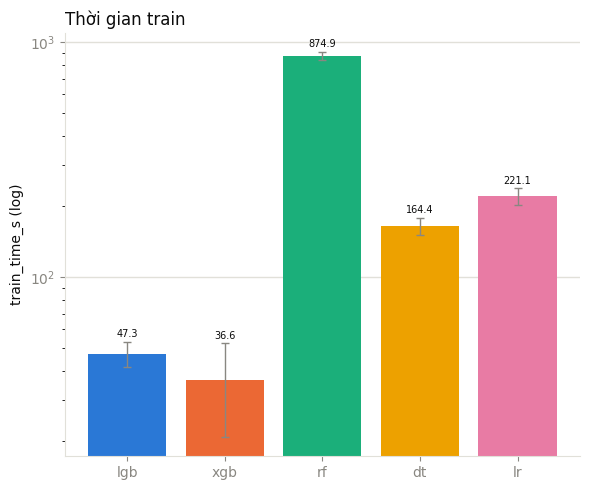

,n_seeds,f1_minority,f1@0.5,precision,recall,pr_auc,recall@fpr1%,precision@1000,train_time_s
model (test),,,,,,,,,
lgb,4,0.6979 ± 0.005,0.6631 ± 0.0033,0.8274 ± 0.018,0.6037 ± 0.0129,0.6798 ± 0.0024,0.8605 ± 0.0071,0.9082 ± 0.0019,47.3 ± 5.9
xgb,4,0.6869 ± 0.0279,0.6415 ± 0.0593,0.8125 ± 0.0751,0.5966 ± 0.0066,0.6638 ± 0.0286,0.8204 ± 0.0283,0.922 ± 0.0128,36.6 ± 15.7
rf,4,0.6554 ± 0.0079,0.5625 ± 0.0064,0.8454 ± 0.007,0.5353 ± 0.0128,0.5579 ± 0.0043,0.6803 ± 0.0194,0.861 ± 0.0022,874.9 ± 32.3
dt,4,0.6008 ± 0.0012,0.1233 ± 0.0004,0.8246 ± 0.0012,0.4726 ± 0.0011,0.4821 ± 0.001,0.6866 ± 0.0017,0.8278 ± 0.001,164.4 ± 13.9
lr,4,0.5049 ± 0.0,0.5108 ± 0.0,0.4166 ± 0.0,0.6407 ± 0.0,0.5582 ± 0.0,0.8176 ± 0.0,0.743 ± 0.0,221.1 ± 17.4


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

METRICS = ["f1_minority", "f1@0.5", "precision", "recall",
           "pr_auc", "recall@fpr1%", "precision@1000", "train_time_s"]
DECIMALS = {"train_time_s": 1}

df = pd.read_csv("results.csv")
n0 = len(df)
df = df.drop_duplicates(subset=["model", "split", "seed"], keep="last")
if n0 != len(df):
    print(f"bỏ {n0 - len(df)}")

test = df[df["split"] == "test"]
g = test.groupby("model")
mean, std = g[METRICS].mean(), g[METRICS].std()

tbl = pd.DataFrame(index=mean.index)
tbl["n_seeds"] = g.size()
for c in METRICS:
    nd = DECIMALS.get(c, 4)
    tbl[c] = mean[c].round(nd).astype(str) + " ± " + std[c].round(nd).astype(str)

order = mean["f1_minority"].sort_values(ascending=False).index
tbl = tbl.loc[order]
tbl.index.name = "model (test)"

# --- vẽ ---
SCORE_METRICS = ["f1_minority", "f1@0.5", "precision", "recall",
                  "pr_auc", "recall@fpr1%", "precision@1000"]
MODEL_COLOR = {
    "lgb": "#2a78d6", "xgb": "#eb6834", "rf": "#1baf7a",
    "dt": "#eda100", "lr": "#e87ba4",
}
INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"
models = list(order)

# --- hình 1: scores theo metric ---
fig1, ax1 = plt.subplots(figsize=(10, 5))
x = np.arange(len(SCORE_METRICS))
width = 0.8 / len(models)
for i, m in enumerate(models):
    color = MODEL_COLOR.get(m, "#898781")
    vals = mean.loc[m, SCORE_METRICS].to_numpy()
    errs = std.loc[m, SCORE_METRICS].to_numpy()
    bars = ax1.bar(x + i * width, vals, width, yerr=errs, capsize=2,
                    color=color, label=m, edgecolor="none", error_kw={"ecolor": MUTED, "elinewidth": 1})
    ax1.bar_label(bars, labels=[f"{v:.2f}" for v in vals], padding=2, fontsize=6, color=INK)

ax1.set_xticks(x + width * (len(models) - 1) / 2)
ax1.set_xticklabels(SCORE_METRICS, rotation=30, ha="right", color=INK)
ax1.set_ylim(0, 1)
ax1.set_ylabel("score", color=INK)
ax1.grid(axis="y", color=GRID, linewidth=1, zorder=0)
ax1.set_axisbelow(True)
for spine in ["top", "right"]:
    ax1.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax1.spines[spine].set_color(GRID)
ax1.tick_params(colors=MUTED)
ax1.set_title("Metrics theo model (test, mean ± std trên seeds)", color=INK, loc="left")
ax1.legend(frameon=False, ncol=len(models), loc="upper center",
           bbox_to_anchor=(0.5, -0.25), labelcolor=INK)
plt.tight_layout()
plt.show()

# --- hình 2: thời gian train ---
fig2, ax2 = plt.subplots(figsize=(6, 5))
for i, m in enumerate(models):
    color = MODEL_COLOR.get(m, "#898781")
    t = mean.loc[m, "train_time_s"]
    bar2 = ax2.bar(i, t, yerr=std.loc[m, "train_time_s"],
                    capsize=3, color=color, edgecolor="none",
                    error_kw={"ecolor": MUTED, "elinewidth": 1})
    ax2.bar_label(bar2, labels=[f"{t:.1f}"], padding=2, fontsize=7, color=INK)
ax2.set_xticks(range(len(models)))
ax2.set_xticklabels(models, color=INK)
ax2.set_yscale("log")
ax2.set_ylabel("train_time_s (log)", color=INK)
ax2.grid(axis="y", color=GRID, linewidth=1, zorder=0)
ax2.set_axisbelow(True)
for spine in ["top", "right"]:
    ax2.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax2.spines[spine].set_color(GRID)
ax2.tick_params(colors=MUTED)
ax2.set_title("Thời gian train", color=INK, loc="left")
plt.tight_layout()
plt.show()

tbl

In [13]:
import pandas as pd

METRICS = ["f1_minority", "pr_auc", "f1@0.5"]

df = pd.read_csv("results-hybrid-v3.csv")
df = df.drop_duplicates(subset=["model", "split", "seed"], keep="last")
df[["arm", "booster"]] = df["model"].str.rsplit("_", n=1, expand=True)

test = df[df["split"] == "test"]
g = test.groupby(["arm", "booster"])
mean, std = g[METRICS].mean(), g[METRICS].std()

tbl = pd.DataFrame(index=mean.index)
tbl["n_seeds"] = g.size()
for c in METRICS:
    tbl[c] = mean[c].round(4).astype(str) + " ± " + std[c].round(4).astype(str)

ARMS = ["baseline", "edge_scalar", "edge_emb", "edge+scalar", "no_edge"]
BOOSTERS = ["lgb", "xgb"]
tbl = tbl.reindex(pd.MultiIndex.from_product([ARMS, BOOSTERS], names=["arm", "booster"]))
tbl

n_seeds      f1_minority           pr_auc  \
arm         booster                                              
baseline    lgb            4  0.6967 ± 0.0039  0.6776 ± 0.0025   
            xgb            4  0.7046 ± 0.0018  0.6873 ± 0.0032   
edge_scalar lgb            4  0.6987 ± 0.0042  0.6874 ± 0.0045   
            xgb            4  0.6886 ± 0.0143  0.6793 ± 0.0229   
edge_emb    lgb            4  0.6933 ± 0.0034  0.6911 ± 0.0049   
            xgb            4  0.7057 ± 0.0053  0.7079 ± 0.0048   
edge+scalar lgb            4   0.6933 ± 0.007   0.6889 ± 0.006   
            xgb            4  0.6967 ± 0.0107  0.7024 ± 0.0133   
no_edge     lgb            4  0.6835 ± 0.0083  0.6743 ± 0.0098   
            xgb            4   0.696 ± 0.0076  0.6926 ± 0.0166   

                              f1@0.5  
arm         booster                   
baseline    lgb       0.6591 ± 0.003  
            xgb       0.678 ± 0.0049  
edge_scalar lgb      0.6514 ± 0.0111  
            xgb       0.6209 ± 0.064  
edge_emb    lgb      0.6454 ± 0.0121  
            xgb      0.6568 ± 0.0085  
edge+scalar lgb      0.6314 ± 0.0206  
            xgb      0.6352 ± 0.0286  
no_edge     lgb      0.6317 ± 0.0098  
            xgb      0.6373 ± 0.0393

In [12]:
import pandas as pd

# xgb/lgb: nhóm 1 classical (results.csv) — thời gian train classifier
df_cls = pd.read_csv("results.csv")
df_cls = df_cls.drop_duplicates(subset=["model", "split", "seed"], keep="last")
df_cls = df_cls[df_cls["model"].isin(["xgb", "lgb"]) & (df_cls["split"] == "test")]

# 4 biến thể encoder GraphSAGE nhóm 2: sage/sage_noedge (results-gnn.csv), sage_lstm/sage_noedge_lstm (results_lstm.csv)
df_gnn = pd.read_csv("results-gnn.csv")
df_lstm = pd.read_csv("results_lstm.csv")
df_gnn = pd.concat([df_gnn, df_lstm], ignore_index=True)
df_gnn = df_gnn.drop_duplicates(subset=["model", "split", "seed"], keep="last")
df_gnn = df_gnn[df_gnn["split"] == "test"]

df = pd.concat([df_cls, df_gnn], ignore_index=True)
g = df.groupby("model")["train_time_s"]
tbl = pd.DataFrame({
    "n_seeds": g.size(),
    "train_time_s (mean±std)": (g.mean().round(1).astype(str) + " ± " + g.std().round(1).astype(str)),
    "train_time_min": (g.mean() / 60).round(2),
})
order = ["xgb", "lgb", "sage", "sage_noedge", "sage_lstm", "sage_noedge_lstm"]
tbl = tbl.reindex(order)
tbl.index.name = "model"

# --- vẽ ---
import matplotlib.pyplot as plt

MODEL_COLOR = {
    "xgb": "#eb6834", "lgb": "#2a78d6",
    "sage": "#1baf7a", "sage_noedge": "#8ed6ba",
    "sage_lstm": "#7c5cbf", "sage_noedge_lstm": "#c3b3e6",
}
INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"
mean, std = g.mean(), g.std()
fig, ax = plt.subplots(figsize=(7, 5))
for i, m in enumerate(order):
    t = mean[m]
    bar = ax.bar(i, t, yerr=std[m], capsize=3, color=MODEL_COLOR[m],
                 edgecolor="none", error_kw={"ecolor": MUTED, "elinewidth": 1})
    ax.bar_label(bar, labels=[f"{t:.1f}"], padding=2, fontsize=8, color=INK)
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, color=INK, rotation=20, ha="right")
ax.set_yscale("log")
ax.set_ylabel("train_time_s (log)", color=INK)
ax.grid(axis="y", color=GRID, linewidth=1, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color(GRID)
ax.tick_params(colors=MUTED)
ax.set_title("Thời gian train: xgb/lgb (classical) vs 4 biến thể GraphSAGE", color=INK, loc="left")
plt.tight_layout()
plt.show()
%matplotlib inline
tbl

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20368\2734570891.py:55: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


,n_seeds,train_time_s (mean±std),train_time_min
model,,,
xgb,4,36.6 ± 15.7,0.61
lgb,4,47.3 ± 5.9,0.79
sage,4,131.2 ± 3.3,2.19
sage_noedge,4,106.1 ± 5.2,1.77
sage_lstm,4,565.1 ± 15.3,9.42
sage_noedge_lstm,4,446.2 ± 10.3,7.44


In [ ]:
import pandas as pd

METRICS = ["f1_minority", "precision", "recall",
           "pr_auc", "recall@fpr1%", "precision@1000", "train_time_s"]
DECIMALS = {"train_time_s": 1}

df = pd.read_csv("results-gnn.csv")
n0 = len(df)
df = df.drop_duplicates(subset=["model", "split", "seed"], keep="last")
if n0 != len(df):
    print(f"Da bo {n0 - len(df)} dong trung theo (model, split, seed), giu lan chay cuoi.")

test = df[df["split"] == "test"]
g = test.groupby("model")
mean, std = g[METRICS].mean(), g[METRICS].std()

tbl = pd.DataFrame(index=mean.index)
tbl["n_seeds"] = g.size()
for c in METRICS:
    nd = DECIMALS.get(c, 4)
    tbl[c] = mean[c].round(nd).astype(str) + " ± " + std[c].round(nd).astype(str)

tbl = tbl.loc[mean["f1_minority"].sort_values(ascending=False).index]
tbl.index.name = "model (test)"
tbl

,n_seeds,f1_minority,precision,recall,pr_auc,recall@fpr1%,precision@1000,train_time_s
model (test),,,,,,,,
sage_noedge,4,0.484 ± 0.0094,0.554 ± 0.0144,0.4299 ± 0.0119,0.4257 ± 0.0145,0.7524 ± 0.0099,0.6423 ± 0.0112,108.4 ± 5.6
sage,4,0.4656 ± 0.0089,0.5507 ± 0.0206,0.4038 ± 0.0154,0.4213 ± 0.0089,0.725 ± 0.0197,0.6295 ± 0.0039,138.3 ± 8.9


In [3]:
import pandas as pd
METRICS=["f1_minority", "precision", "recall","pr_auc", "recall@fpr1%", "precision@1000", "train_time_s"]
DECIMALS={"train_time":1}
df_gnn = pd.read_csv("results-gnn.csv")
df_lstm = pd.read_csv("results-LSTM.csv")
df = pd.concat([df_gnn, df_lstm], ignore_index=True)
test = df[df["split"] == "test"]
g = test.groupby("model")
mean, std = g[METRICS].mean(), g[METRICS].std()

tbl = pd.DataFrame(index=mean.index)
tbl["n_seeds"] = g.size()
for c in METRICS:
    nd = DECIMALS.get(c, 4)
    tbl[c] = mean[c].round(nd).astype(str) + " ± " + std[c].round(nd).astype(str)

tbl = tbl.loc[mean["f1_minority"].sort_values(ascending=False).index]
tbl.index.name = "model (test)"
tbl

,n_seeds,f1_minority,precision,recall,pr_auc,recall@fpr1%,precision@1000,train_time_s
model (test),,,,,,,,
sage_lstm,4,0.5049 ± 0.0203,0.5914 ± 0.0449,0.4454 ± 0.053,0.493 ± 0.0281,0.766 ± 0.0215,0.6905 ± 0.0348,317.6 ± 12.2521
sage_noedge_lstm,4,0.4877 ± 0.0095,0.5808 ± 0.0236,0.4217 ± 0.0266,0.4538 ± 0.0123,0.7664 ± 0.0132,0.6528 ± 0.0128,288.625 ± 10.1438
sage_noedge,4,0.484 ± 0.0094,0.554 ± 0.0144,0.4299 ± 0.0119,0.4257 ± 0.0145,0.7524 ± 0.0099,0.6423 ± 0.0112,108.45 ± 5.5752
sage,4,0.4656 ± 0.0089,0.5507 ± 0.0206,0.4038 ± 0.0154,0.4213 ± 0.0089,0.725 ± 0.0197,0.6295 ± 0.0039,138.325 ± 8.8947


In [ ]:
#HID=32 thay scores/final-32/ ở s_val và s_test
import numpy as np, pandas as pd
from sklearn.metrics import f1_score

import paths
from metrics import find_best_threshold

ARMS = ["baseline", "edge_scalar", "edge_emb", "edge+scalar", "no_edge"]
BOOSTERS = ["lgb", "xgb"]
SEEDS = [0, 1, 2, 3]

labels = pd.read_parquet(paths.TX_FEAT, columns=["Is Laundering", "split"])
y_val = labels.loc[labels["split"] == "val", "Is Laundering"].to_numpy()
y_test = labels.loc[labels["split"] == "test", "Is Laundering"].to_numpy()
rows = []
for arm in ARMS:
    for booster in BOOSTERS:
        tag = f"{arm}_{booster}"
        for seed in SEEDS:
            s_val = np.load(f"scores/final/{tag}_seed{seed}_val.npy")
            s_test = np.load(f"scores/final/{tag}_seed{seed}_test.npy")
            thr = find_best_threshold(y_val, s_val)
            pred = (s_test >= thr).astype(int)
            rows.append({"arm": arm, "booster": booster, "seed": seed,
                         "f1": f1_score(y_test, pred, pos_label=1, zero_division=0)})

r = pd.DataFrame(rows)
w = r.pivot_table(index=["booster", "seed"], columns="arm", values="f1")
print("=== hiệu ghép cặp theo seed (f1_minority, tag results-hybrid-v3) ===")
print(pd.DataFrame({
    "edge_emb-baseline":    w["edge_emb"]    - w["baseline"],
    "edge_scalar-baseline": w["edge_scalar"] - w["baseline"],
    "edge+scalar-baseline": w["edge+scalar"] - w["baseline"],
    "no_edge-baseline":     w["no_edge"]     - w["baseline"],
}).round(4))

=== hiệu ghép cặp theo seed (f1_minority, tag results-hybrid-v3) ===
              edge_emb-baseline  edge_scalar-baseline  edge+scalar-baseline  \
booster seed                                                                  
lgb     0               -0.0092                0.0006               -0.0049   
        1                0.0041                0.0149               -0.0010   
        2               -0.0091                0.0148               -0.0012   
        3               -0.0158                0.0107               -0.0102   
xgb     0               -0.0083                0.0079               -0.0155   
        1               -0.0280               -0.0002               -0.0246   
        2               -0.0258               -0.0222               -0.0110   
        3               -0.0070                0.0067               -0.0194   

              no_edge-baseline  
booster seed                    
lgb     0              -0.0019  
        1              -0.0184  
        

In [8]:
#HID=16
import numpy as np, pandas as pd
from sklearn.metrics import f1_score

import paths
from metrics import find_best_threshold

ARMS = ["baseline", "edge_scalar", "edge_emb", "edge+scalar", "no_edge"]
BOOSTERS = ["lgb", "xgb"]
SEEDS = [0, 1, 2, 3]

labels = pd.read_parquet(paths.TX_FEAT, columns=["Is Laundering", "split"])
y_val = labels.loc[labels["split"] == "val", "Is Laundering"].to_numpy()
y_test = labels.loc[labels["split"] == "test", "Is Laundering"].to_numpy()
rows = []
for arm in ARMS:
    for booster in BOOSTERS:
        tag = f"{arm}_{booster}"
        for seed in SEEDS:
            s_val = np.load(f"scores/final/{tag}_seed{seed}_val.npy")
            s_test = np.load(f"scores/final/{tag}_seed{seed}_test.npy")
            thr = find_best_threshold(y_val, s_val)
            pred = (s_test >= thr).astype(int)
            rows.append({"arm": arm, "booster": booster, "seed": seed,
                         "f1": f1_score(y_test, pred, pos_label=1, zero_division=0)})

r = pd.DataFrame(rows)
w = r.pivot_table(index=["booster", "seed"], columns="arm", values="f1")
print("=== hiệu ghép cặp theo seed (f1_minority, tag results-hybrid-v3) ===")
print(pd.DataFrame({
    "edge_emb-baseline":    w["edge_emb"]    - w["baseline"],
    "edge_scalar-baseline": w["edge_scalar"] - w["baseline"],
    "edge+scalar-baseline": w["edge+scalar"] - w["baseline"],
    "no_edge-baseline":     w["no_edge"]     - w["baseline"],
}).round(4))

=== hiệu ghép cặp theo seed (f1_minority, tag results-hybrid-v3) ===
              edge_emb-baseline  edge_scalar-baseline  edge+scalar-baseline  \
booster seed                                                                  
lgb     0               -0.0069                0.0044               -0.0020   
        1                0.0070                0.0079               -0.0084   
        2               -0.0088               -0.0080               -0.0043   
        3               -0.0047                0.0038                0.0012   
xgb     0               -0.0061               -0.0158               -0.0187   
        1                0.0029               -0.0203               -0.0176   
        2                0.0036                0.0038                0.0013   
        3                0.0042               -0.0314                0.0034   

              no_edge-baseline  
booster seed                    
lgb     0              -0.0214  
        1              -0.0126  
        

In [7]:
import pandas as pd
files = {
    "hybrid": "results-hybrid-v3.csv",
    "lstm": "results_lstm.csv",
    "baseline": "results.csv",
}
df_all = pd.concat(
    [pd.read_csv(path).assign(group=name) for name, path in files.items()],
    ignore_index=True,
)
df_all
metrics = ["f1_minority", "pr_auc", "recall@fpr1%"]
summary = (
    df_all.groupby(["group", "model", "split"])[metrics]
    .agg(["mean", "std"])
    .round(4)
)
summary

f1_minority          pr_auc          \
                                       mean     std    mean     std   
group    model            split                                       
baseline dt               test       0.6008  0.0012  0.4821  0.0010   
                          val        0.5254  0.0020  0.4021  0.0016   
         lgb              test       0.6979  0.0050  0.6798  0.0024   
                          val        0.6177  0.0035  0.5807  0.0028   
         lr               test       0.5049  0.0000  0.5582  0.0000   
                          val        0.4876  0.0000  0.4440  0.0000   
         rf               test       0.6554  0.0079  0.5579  0.0043   
                          val        0.5858  0.0031  0.4848  0.0031   
         xgb              test       0.6869  0.0279  0.6638  0.0286   
                          val        0.6330  0.0108  0.5940  0.0140   
hybrid   baseline_lgb     test       0.6978     NaN  0.6789     NaN   
                          val        0.6246     NaN  0.5906     NaN   
         baseline_xgb     test       0.7042     NaN  0.6833     NaN   
                          val        0.6339     NaN  0.6002     NaN   
lstm     sage_lstm        test       0.5274  0.0189  0.5063  0.0233   
                          val        0.4466  0.0062  0.4078  0.0066   
         sage_noedge_lstm test       0.4691  0.0196  0.4307  0.0227   
                          val        0.4104  0.0119  0.3700  0.0094   

                                recall@fpr1%          
                                        mean     std  
group    model            split                       
baseline dt               test        0.6866  0.0017  
                          val         0.6131  0.0023  
         lgb              test        0.8605  0.0071  
                          val         0.8089  0.0076  
         lr               test        0.8176  0.0000  
                          val         0.7874  0.0000  
         rf               test        0.6803  0.0194  
                          val         0.6564  0.0111  
         xgb              test        0.8204  0.0283  
                          val         0.7983  0.0141  
hybrid   baseline_lgb     test        0.8376     NaN  
                          val         0.8189     NaN  
         baseline_xgb     test        0.8337     NaN  
                          val         0.8142     NaN  
lstm     sage_lstm        test        0.8070  0.0071  
                          val         0.7669  0.0251  
         sage_noedge_lstm test        0.7602  0.0121  
                          val         0.7560  0.0017

In [ ]:
import numpy as np, pandas as pd
from sklearn.metrics import f1_score

import paths
from metrics import find_best_threshold

ARMS = ["baseline", "edge_scalar", "edge_emb", "edge+scalar", "no_edge"]
BOOSTERS = ["lgb", "xgb"]
SEEDS = [0, 1, 2, 3]

labels = pd.read_parquet(paths.TX_FEAT, columns=["Is Laundering", "split"])
y_val = labels.loc[labels["split"] == "val", "Is Laundering"].to_numpy()
y_test = labels.loc[labels["split"] == "test", "Is Laundering"].to_numpy()

rows = []
for arm in ARMS:
    for booster in BOOSTERS:
        tag = f"{arm}_{booster}"
        for seed in SEEDS:
            s_val = np.load(f"scores/final/{tag}_seed{seed}_val.npy")
            s_test = np.load(f"scores/final/{tag}_seed{seed}_test.npy")
            thr = find_best_threshold(y_val, s_val)
            pred = (s_test >= thr).astype(int)
            rows.append({"arm": arm, "booster": booster, "seed": seed,
                         "f1": f1_score(y_test, pred, pos_label=1, zero_division=0)})

r = pd.DataFrame(rows)
w = r.pivot_table(index=["booster", "seed"], columns="arm", values="f1")
print("=== hiệu ghép cặp theo seed (f1_minority, tag results-hybrid-v3) ===")
print(pd.DataFrame({
    "edge_emb-baseline":    w["edge_emb"]    - w["baseline"],
    "edge_scalar-baseline": w["edge_scalar"] - w["baseline"],
    "edge+scalar-baseline": w["edge+scalar"] - w["baseline"],
    "no_edge-baseline":     w["no_edge"]     - w["baseline"],
}).round(4))


In [ ]:
import pandas as pd

# xgb/lgb: nhóm 1 classical (results.csv) — thời gian train classifier
df_cls = pd.read_csv("results.csv")
df_cls = df_cls.drop_duplicates(subset=["model", "split", "seed"], keep="last")
df_cls = df_cls[df_cls["model"].isin(["xgb", "lgb"]) & (df_cls["split"] == "test")]

# 4 biến thể encoder GraphSAGE nhóm 2: sage/sage_noedge (results-gnn.csv), sage_lstm/sage_noedge_lstm (results_lstm.csv)
df_gnn = pd.read_csv("results-gnn.csv")
df_lstm = pd.read_csv("results_lstm.csv")
df_gnn = pd.concat([df_gnn, df_lstm], ignore_index=True)
df_gnn = df_gnn.drop_duplicates(subset=["model", "split", "seed"], keep="last")
df_gnn = df_gnn[df_gnn["split"] == "test"]

df = pd.concat([df_cls, df_gnn], ignore_index=True)
g = df.groupby("model")["train_time_s"]

tbl = pd.DataFrame({
    "n_seeds": g.size(),
    "train_time_s (mean±std)": (g.mean().round(1).astype(str) + " ± " + g.std().round(1).astype(str)),
    "train_time_min": (g.mean() / 60).round(2),
})
order = ["xgb", "lgb", "sage", "sage_noedge", "sage_lstm", "sage_noedge_lstm"]
tbl = tbl.reindex(order)
tbl.index.name = "model"

# --- vẽ ---
import matplotlib.pyplot as plt

MODEL_COLOR = {
    "xgb": "#eb6834", "lgb": "#2a78d6",
    "sage": "#1baf7a", "sage_noedge": "#8ed6ba",
    "sage_lstm": "#7c5cbf", "sage_noedge_lstm": "#c3b3e6",
}
INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"
mean, std = g.mean(), g.std()

fig, ax = plt.subplots(figsize=(7, 5))
for i, m in enumerate(order):
    t = mean[m]
    bar = ax.bar(i, t, yerr=std[m], capsize=3, color=MODEL_COLOR[m],
                 edgecolor="none", error_kw={"ecolor": MUTED, "elinewidth": 1})
    ax.bar_label(bar, labels=[f"{t:.1f}"], padding=2, fontsize=8, color=INK)
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, color=INK, rotation=20, ha="right")
ax.set_yscale("log")
ax.set_ylabel("train_time_s (log)", color=INK)
ax.grid(axis="y", color=GRID, linewidth=1, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color(GRID)
ax.tick_params(colors=MUTED)
ax.set_title("Thời gian train: xgb/lgb (classical) vs 4 biến thể GraphSAGE", color=INK, loc="left")
plt.tight_layout()
plt.show()

tbl
